i


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os, cv2, yaml, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter, defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

In [ ]:
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATASET_PATH = '/content/drive/MyDrive/bone fracture detection.'
EPOCHS       = 30
BATCH_SIZE   = 6
LR           = 0.005
IMG_SIZE     = 512
IOU_THRESH   = 0.5   # for matching predictions → GT
CONF_THRESH  = 0.4   # minimum score to consider a prediction

#print(f"Device: {DEVICE}")

In [ ]:
import os
import shutil

def filter_annotated_images(root_path, split):
    """
    Keeps only images that have labels in the dataset split.
    Moves unannotated images to a separate folder for backup.
    """
    img_dir = os.path.join(root_path, split, 'images')
    lbl_dir = os.path.join(root_path, split, 'labels')
    backup_dir = os.path.join(root_path, split, 'images_no_labels')
    os.makedirs(backup_dir, exist_ok=True)

    removed = 0
    for img_file in os.listdir(img_dir):
        lbl_file = img_file.replace('.jpg', '.txt')
        lbl_path = os.path.join(lbl_dir, lbl_file)

        # If label file doesn't exist or empty, move image to backup
        if not os.path.exists(lbl_path) or os.path.getsize(lbl_path) == 0:
            shutil.move(os.path.join(img_dir, img_file),
                        os.path.join(backup_dir, img_file))
            removed += 1

    print(f"{removed} images without labels moved from {split} set")

In [ ]:
DATASET_PATH = '/content/drive/MyDrive/bone fracture detection.'

for split in ['train', 'valid', 'test']:
    filter_annotated_images(DATASET_PATH, split)

1827 images without labels moved from train set
175 images without labels moved from valid set
86 images without labels moved from test set


In [ ]:
import os
import shutil
import random
from collections import defaultdict

def move_to_validation(dataset_path, val_ratio=0.2):
    train_img_dir = os.path.join(dataset_path, 'train/images')
    train_lbl_dir = os.path.join(dataset_path, 'train/labels')

    val_img_dir = os.path.join(dataset_path, 'valid/images')
    val_lbl_dir = os.path.join(dataset_path, 'valid/labels')

    os.makedirs(val_img_dir, exist_ok=True)
    os.makedirs(val_lbl_dir, exist_ok=True)

    # Group images by class
    class_to_images = defaultdict(list)

    for lbl_file in os.listdir(train_lbl_dir):
        lbl_path = os.path.join(train_lbl_dir, lbl_file)

        if os.path.getsize(lbl_path) == 0:
            continue

        with open(lbl_path, 'r') as f:
            classes = [line.split()[0] for line in f.readlines()]

        # Use majority class (or first class)
        main_class = classes[0]
        img_file = lbl_file.replace('.txt', '.jpg')

        class_to_images[main_class].append((img_file, lbl_file))

    # Move images per class
    total_moved = 0

    for cls, files in class_to_images.items():
        random.shuffle(files)
        n_move = int(len(files) * val_ratio)

        for img_file, lbl_file in files[:n_move]:
            # Paths
            src_img = os.path.join(train_img_dir, img_file)
            src_lbl = os.path.join(train_lbl_dir, lbl_file)

            dst_img = os.path.join(val_img_dir, img_file)
            dst_lbl = os.path.join(val_lbl_dir, lbl_file)

            if os.path.exists(src_img) and os.path.exists(src_lbl):
                shutil.move(src_img, dst_img)
                shutil.move(src_lbl, dst_lbl)
                total_moved += 1

    print(f"Moved {total_moved} images to validation set")

In [ ]:
move_to_validation(DATASET_PATH, val_ratio=0.2)

Moved 358 images to validation set


i


In [ ]:

# Dataset counts
counts = {s: len(os.listdir(os.path.join(DATASET_PATH, s, 'images')))
          for s in ['train', 'valid', 'test']}
print("\nDataset sizes:", counts)

with open(os.path.join(DATASET_PATH, 'data.yaml')) as f:
    data_yaml = yaml.safe_load(f)
CLASS_NAMES = data_yaml['names']
NUM_CLASSES = len(CLASS_NAMES) + 1   # +1 for background
print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")


Dataset sizes: {'train': 1446, 'valid': 531, 'test': 83}
Classes (7): ['elbow positive', 'fingers positive', 'forearm fracture', 'humerus fracture', 'humerus', 'shoulder fracture', 'wrist positive']


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Split distribution
axes[0].bar(counts.keys(), counts.values(), color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('Dataset Split Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Images')
for bar, v in zip(axes[0].patches, counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(v), ha='center', va='bottom', fontsize=11)
# Class distribution
counter = Counter()
for file in os.listdir(os.path.join(DATASET_PATH, 'train', 'labels')):
    with open(os.path.join(DATASET_PATH, 'train', 'labels', file)) as f:
        for line in f:
            counter[int(line.split()[0])] += 1

names  = [CLASS_NAMES[i] for i in sorted(counter.keys())]
values = [counter[i] for i in sorted(counter.keys())]
colors = plt.cm.tab20(np.linspace(0, 1, len(names)))
axes[1].barh(names, values, color=colors)
axes[1].set_title('Class Distribution (Train)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved.")

In [ ]:
def get_transforms(train=True):
    if train:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.3),
            A.CLAHE(p=0.3),
            A.Affine(scale=(0.9, 1.1), rotate=(-10, 10), p=0.4),
            A.GaussianBlur(p=0.15),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'], min_visibility=0.3))
    else:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))


In [ ]:
class BoneDataset(Dataset):
    def __init__(self, root, split, transforms=None):
        self.img_dir    = os.path.join(root, split, 'images')
        self.lbl_dir    = os.path.join(root, split, 'labels')
        self.transforms = transforms
        self.images     = sorted(os.listdir(self.img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        lbl_path = os.path.join(self.lbl_dir, img_name.replace('.jpg', '.txt'))

        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        boxes, labels = [], []
        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                for line in f:
                    vals = list(map(float, line.split()))
                    cls  = int(vals[0])
                    xs   = vals[1::2];  ys = vals[2::2]
                    xmin, xmax = min(xs)*w, max(xs)*w
                    ymin, ymax = min(ys)*h, max(ys)*h
                    if xmax > xmin and ymax > ymin:
                        boxes.append([xmin, ymin, xmax, ymax])
                        labels.append(cls + 1)

        if len(boxes) == 0:
            return self.__getitem__((idx + 1) % len(self))

        if self.transforms:
            t       = self.transforms(image=img, bboxes=boxes, labels=labels)
            img     = t['image']
            boxes   = t['bboxes']
            labels  = t['labels']

        return img, {
            "boxes":  torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64)
        }


In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_ds = BoneDataset(DATASET_PATH, 'train', get_transforms(True))
val_ds   = BoneDataset(DATASET_PATH, 'valid', get_transforms(False))
test_ds  = BoneDataset(DATASET_PATH, 'test',  get_transforms(False))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Train: 1446 | Val: 531 | Test: 83


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_augmentations(dataset, num_images=4):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    for i in range(num_images):
        img, target = dataset[i]

        # Convert tensor → numpy
        img_np = img.permute(1, 2, 0).cpu().numpy()

        # Denormalise (ImageNet stats)
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)

        axes[i].imshow(img_np)
        axes[i].axis('off')

        # Draw bounding boxes
        for box in target["boxes"]:
            x1, y1, x2, y2 = box
            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )
            axes[i].add_patch(rect)

    plt.tight_layout()
    plt.show()

In [ ]:
visualize_augmentations(train_ds)

In [ ]:
def build_model(num_classes):
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = build_model(NUM_CLASSES).to(DEVICE)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LR, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
print(f"Model ready — {sum(p.numel() for p in model.parameters()):,} parameters")


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 233MB/s]


Model ready — 41,329,911 parameters


In [ ]:
def box_iou(box_a, box_b):
    """Compute IoU between two [x1,y1,x2,y2] tensors."""
    inter_x1 = torch.max(box_a[:, None, 0], box_b[None, :, 0])
    inter_y1 = torch.max(box_a[:, None, 1], box_b[None, :, 1])
    inter_x2 = torch.min(box_a[:, None, 2], box_b[None, :, 2])
    inter_y2 = torch.min(box_a[:, None, 3], box_b[None, :, 3])
    inter_w  = (inter_x2 - inter_x1).clamp(min=0)
    inter_h  = (inter_y2 - inter_y1).clamp(min=0)
    inter    = inter_w * inter_h
    area_a   = (box_a[:, 2]-box_a[:, 0]) * (box_a[:, 3]-box_a[:, 1])
    area_b   = (box_b[:, 2]-box_b[:, 0]) * (box_b[:, 3]-box_b[:, 1])
    union    = area_a[:, None] + area_b[None, :] - inter
    return inter / union.clamp(min=1e-6)



In [ ]:
def evaluate_epoch(model, loader, iou_thresh=IOU_THRESH, conf_thresh=CONF_THRESH):
    """
    Returns per-class TP, FP, FN counts and overall precision/recall/mAP50.
    Also returns raw prediction/GT pairs for confusion matrix.
    """
    model.eval()
    all_tp = defaultdict(int)
    all_fp = defaultdict(int)
    all_fn = defaultdict(int)
    pred_labels_all = []
    true_labels_all = []

    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(DEVICE) for img in images]
            preds  = model(images)

            for pred, tgt in zip(preds, targets):
                gt_boxes  = tgt['boxes'].cpu()
                gt_labels = tgt['labels'].cpu()

                # Filter by confidence
                keep       = pred['scores'].cpu() >= conf_thresh
                pb         = pred['boxes'].cpu()[keep]
                pl         = pred['labels'].cpu()[keep]

                matched_gt = set()

                for i, (pbox, plabel) in enumerate(zip(pb, pl)):
                    if len(gt_boxes) == 0:
                        all_fp[plabel.item()] += 1
                        pred_labels_all.append(plabel.item())
                        true_labels_all.append(0)  # background
                        continue

                    ious = box_iou(pbox.unsqueeze(0), gt_boxes)[0]
                    best_iou, best_j = ious.max(0)
                    best_j = best_j.item()

                    if best_iou >= iou_thresh and best_j not in matched_gt:
                        if plabel == gt_labels[best_j]:
                            all_tp[plabel.item()] += 1
                            matched_gt.add(best_j)
                            pred_labels_all.append(plabel.item())
                            true_labels_all.append(gt_labels[best_j].item())
                        else:
                            all_fp[plabel.item()] += 1
                            pred_labels_all.append(plabel.item())
                            true_labels_all.append(gt_labels[best_j].item())
                    else:
                        all_fp[plabel.item()] += 1
                        pred_labels_all.append(plabel.item())
                        true_labels_all.append(0)

                for j in range(len(gt_boxes)):
                    if j not in matched_gt:
                        all_fn[gt_labels[j].item()] += 1

    # Per-class P/R/F1
    results = {}
    for cls_id in range(1, NUM_CLASSES):
        tp = all_tp[cls_id];  fp = all_fp[cls_id];  fn = all_fn[cls_id]
        p  = tp / (tp + fp + 1e-6)
        r  = tp / (tp + fn + 1e-6)
        f1 = 2*p*r / (p + r + 1e-6)
        results[cls_id] = dict(tp=tp, fp=fp, fn=fn, precision=p, recall=r, f1=f1)

    mean_p  = np.mean([v['precision'] for v in results.values()])
    mean_r  = np.mean([v['recall']    for v in results.values()])
    mean_f1 = np.mean([v['f1']        for v in results.values()])

    return results, mean_p, mean_r, mean_f1, pred_labels_all, true_labels_all


i


In [ ]:
history = {
    'train_loss': [],
    'val_precision': [], 'val_recall': [], 'val_f1': []
}
best_f1    = 0.0
SAVE_PATH  = 'best_model.pth'

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    epoch_loss = 0.0

    for batch_idx, (images, targets) in enumerate(train_loader):
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses    = sum(loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        epoch_loss += losses.item()

    avg_loss = epoch_loss / len(train_loader)
    history['train_loss'].append(avg_loss)

    # ── Validate ──
    results, mp, mr, mf1, _, _ = evaluate_epoch(model, val_loader)
    history['val_precision'].append(mp)
    history['val_recall'].append(mr)
    history['val_f1'].append(mf1)

    scheduler.step()

    # ── Save best ──
    if mf1 > best_f1:
        best_f1 = mf1
        torch.save(model.state_dict(), SAVE_PATH)
        star = '★'
    else:
        star = ' '

    print(f"Epoch [{epoch:02d}/{EPOCHS}] {star}  "
          f"Loss: {avg_loss:.4f}  "
          f"P: {mp:.3f}  R: {mr:.3f}  F1: {mf1:.3f}  "
          f"(best F1: {best_f1:.3f})")

print(f"\nTraining complete. Best val F1 = {best_f1:.4f}")



i


In [ ]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Metrics — Faster R-CNN (Bone Fracture Detection)',
             fontsize=14, fontweight='bold', y=1.01)

# Training Loss
axes[0, 0].plot(epochs_range, history['train_loss'], color='#C44E52', linewidth=2)
axes[0, 0].fill_between(epochs_range, history['train_loss'], alpha=0.15, color='#C44E52')
axes[0, 0].set_title('Training Loss');  axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

# Precision
axes[0, 1].plot(epochs_range, history['val_precision'], color='#4C72B0', linewidth=2)
axes[0, 1].fill_between(epochs_range, history['val_precision'], alpha=0.15, color='#4C72B0')
axes[0, 1].set_title('Val Precision'); axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_ylim(0, 1);  axes[0, 1].grid(True, alpha=0.3)

# Recall
axes[1, 0].plot(epochs_range, history['val_recall'], color='#55A868', linewidth=2)
axes[1, 0].fill_between(epochs_range, history['val_recall'], alpha=0.15, color='#55A868')
axes[1, 0].set_title('Val Recall');    axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_ylim(0, 1);  axes[1, 0].grid(True, alpha=0.3)

# F1 Score
axes[1, 1].plot(epochs_range, history['val_f1'], color='#DD8452', linewidth=2)
axes[1, 1].fill_between(epochs_range, history['val_f1'], alpha=0.15, color='#DD8452')
axes[1, 1].set_title('Val F1 Score'); axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('F1')
axes[1, 1].set_ylim(0, 1);  axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Metric plots saved → training_metrics.png")

In [ ]:
# Load best model for final evaluation
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
results, mp, mr, mf1, pred_labels_all, true_labels_all = evaluate_epoch(model, val_loader)

cls_names = [CLASS_NAMES[i-1] for i in range(1, NUM_CLASSES)]
precisions = [results[i]['precision'] for i in range(1, NUM_CLASSES)]
recalls    = [results[i]['recall']    for i in range(1, NUM_CLASSES)]
f1s        = [results[i]['f1']        for i in range(1, NUM_CLASSES)]

x   = np.arange(len(cls_names))
w   = 0.25
fig, ax = plt.subplots(figsize=(max(10, len(cls_names)*1.5), 5))
ax.bar(x - w, precisions, w, label='Precision', color='#4C72B0', alpha=0.85)
ax.bar(x,      recalls,    w, label='Recall',    color='#55A868', alpha=0.85)
ax.bar(x + w,  f1s,        w, label='F1',        color='#DD8452', alpha=0.85)
ax.set_xticks(x);  ax.set_xticklabels(cls_names, rotation=45, ha='right')
ax.set_ylim(0, 1.05);  ax.set_ylabel('Score');  ax.legend()
ax.set_title('Per-Class Precision / Recall / F1  (Val Set)', fontsize=13, fontweight='bold')
ax.axhline(mp,  color='#4C72B0', linestyle='--', linewidth=0.8, alpha=0.6, label=f'Mean P={mp:.2f}')
ax.axhline(mr,  color='#55A868', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(mf1, color='#DD8452', linestyle='--', linewidth=0.8, alpha=0.6)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Per-class plot saved → per_class_metrics.png")

In [ ]:
all_labels = list(range(0, NUM_CLASSES))
label_names = ['background'] + CLASS_NAMES

# Filter to only pairs that actually appear
unique_in_data = sorted(set(true_labels_all + pred_labels_all))
display_names  = [label_names[i] for i in unique_in_data]

cm = confusion_matrix(true_labels_all, pred_labels_all, labels=unique_in_data)

fig, ax = plt.subplots(figsize=(max(8, len(display_names)), max(7, len(display_names)-1)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=display_names, yticklabels=display_names,
            linewidths=0.5, linecolor='grey', ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix — Bone Fracture Detection (Val Set)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved → confusion_matrix.png")

# Normalised version (row-wise recall heatmap)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)
fig, ax = plt.subplots(figsize=(max(8, len(display_names)), max(7, len(display_names)-1)))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=display_names, yticklabels=display_names,
            vmin=0, vmax=1, linewidths=0.5, linecolor='grey', ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Normalised Confusion Matrix (Row = True Class)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix_normalised.png', dpi=150, bbox_inches='tight')
plt.show()
print("Normalised confusion matrix saved → confusion_matrix_normalised.png")

In [ ]:
DENORM_MEAN = np.array([0.485, 0.456, 0.406])
DENORM_STD  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    img = tensor.permute(1, 2, 0).cpu().numpy()
    img = img * DENORM_STD + DENORM_MEAN
    return np.clip(img, 0, 1)

def draw_boxes(ax, img, pred_boxes, pred_labels, pred_scores,
               gt_boxes=None, gt_labels=None,
               class_names=CLASS_NAMES, conf_thresh=CONF_THRESH):
    ax.imshow(img)
    cmap = plt.cm.tab20(np.linspace(0, 1, len(class_names)))

    # Ground truth (dashed green)
    if gt_boxes is not None:
        for box, lbl in zip(gt_boxes, gt_labels):
            x1, y1, x2, y2 = box
            rect = mpatches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor='lime', facecolor='none', linestyle='--')
            ax.add_patch(rect)
            ax.text(x1, y1-2, CLASS_NAMES[lbl-1], color='lime',
                    fontsize=7, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none'))

    # Predictions (solid, colour-coded by class)
    for box, lbl, score in zip(pred_boxes, pred_labels, pred_scores):
        if score < conf_thresh:
            continue
        x1, y1, x2, y2 = box
        color = cmap[lbl % len(cmap)]
        rect  = mpatches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        cls_name = CLASS_NAMES[lbl-1] if lbl-1 < len(CLASS_NAMES) else f'cls{lbl}'
        ax.text(x1, y2+10, f'{cls_name} {score:.2f}',
                color='white', fontsize=7, fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.7, pad=1, edgecolor='none'))
    ax.axis('off')


# Run on test set and visualise N_SHOW random samples
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

N_SHOW   = 12
test_img_dir = os.path.join(DATASET_PATH, 'test', 'images')
test_lbl_dir = os.path.join(DATASET_PATH, 'test', 'labels')
img_files    = sorted(os.listdir(test_img_dir))
sample_files = random.sample(img_files, min(N_SHOW, len(img_files)))

COLS = 3
ROWS = (N_SHOW + COLS - 1) // COLS
fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 5, ROWS * 4.5))
axes_flat  = axes.flatten()

for ax_idx, img_name in enumerate(sample_files):
    ax = axes_flat[ax_idx]

    # Load & predict
    img_path = os.path.join(test_img_dir, img_name)
    lbl_path = os.path.join(test_lbl_dir,  img_name.replace('.jpg', '.txt'))

    raw_img  = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w     = raw_img.shape[:2]

    # Preprocess
    tf    = get_transforms(train=False)
    dummy = tf(image=raw_img, bboxes=[], labels=[])
    inp   = dummy['image'].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out = model(inp)[0]

    disp_img = denormalize(dummy['image'])

    # Ground truth from label file
    gt_boxes, gt_labels = [], []
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                vals = list(map(float, line.split()))
                cls  = int(vals[0])
                xs   = vals[1::2]; ys = vals[2::2]
                gt_boxes.append([min(xs)*IMG_SIZE, min(ys)*IMG_SIZE,
                                  max(xs)*IMG_SIZE, max(ys)*IMG_SIZE])
                gt_labels.append(cls + 1)

    draw_boxes(
        ax, disp_img,
        out['boxes'].cpu().numpy(),
        out['labels'].cpu().numpy(),
        out['scores'].cpu().numpy(),
        gt_boxes=np.array(gt_boxes) if gt_boxes else None,
        gt_labels=gt_labels
    )
    ax.set_title(img_name[:30], fontsize=8)

# Hide unused axes
for ax in axes_flat[len(sample_files):]:
    ax.axis('off')

# Legend
gt_patch   = mpatches.Patch(edgecolor='lime',  facecolor='none', linestyle='--', linewidth=2, label='Ground truth')
pred_patch = mpatches.Patch(edgecolor='deepskyblue', facecolor='none', linewidth=2, label='Prediction')
fig.legend(handles=[gt_patch, pred_patch], loc='lower center',
           ncol=2, fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.01))

fig.suptitle('Test Set Predictions — Faster R-CNN\n'
             '(dashed lime = GT  |  solid = prediction  |  colour = class)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Test predictions saved → test_predictions.png")

In [ ]:
test_results, test_p, test_r, test_f1, _, _ = evaluate_epoch(model, test_loader)

print("\n" + "="*55)
print("  FINAL TEST METRICS")
print("="*55)
print(f"  {'Class':<22} {'P':>6} {'R':>6} {'F1':>6}")
print("-"*55)
for cls_id in range(1, NUM_CLASSES):
    cls_name = CLASS_NAMES[cls_id-1]
    v = test_results[cls_id]
    print(f"  {cls_name:<22} {v['precision']:>6.3f} {v['recall']:>6.3f} {v['f1']:>6.3f}")
print("-"*55)
print(f"  {'mAP (mean F1)':<22} {test_p:>6.3f} {test_r:>6.3f} {test_f1:>6.3f}")
print("="*55)


  FINAL TEST METRICS
  Class                       P      R     F1
-------------------------------------------------------
  elbow positive          0.167  0.059  0.087
  fingers positive        0.241  0.259  0.250
  forearm fracture        0.600  0.429  0.500
  humerus fracture        0.000  0.000  0.000
  humerus                 0.385  0.333  0.357
  shoulder fracture       0.308  0.235  0.267
  wrist positive          0.167  0.333  0.222
-------------------------------------------------------
  mAP (mean F1)           0.267  0.236  0.240


In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
MODEL_SIZE = 'yolov8n.pt'
model = YOLO(MODEL_SIZE)

results = model.train(
    data=os.path.join(DATASET_PATH, 'data.yaml'),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    project='yolo_runs',
    name='bone_fracture',
    verbose=True
)

In [ ]:
import glob

results_csv = glob.glob('/content/runs/detect/**/results.csv', recursive=True)[-1]
df = pd.read_csv(results_csv)

In [ ]:


# Extract metrics
history = {
    'precision': df['metrics/precision(B)'],
    'recall': df['metrics/recall(B)'],
    'f1': 2 * (df['metrics/precision(B)'] * df['metrics/recall(B)']) /
          (df['metrics/precision(B)'] + df['metrics/recall(B)'] + 1e-6),
    'mAP50': df['metrics/mAP50(B)'],
    'loss': df['train/box_loss']
}

In [ ]:
epochs_range = range(1, len(history['precision']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('YOLOv8 Training Metrics — Bone Fracture Detection',
             fontsize=14, fontweight='bold')

# Loss
axes[0, 0].plot(epochs_range, history['loss'])
axes[0, 0].set_title('Training Loss')

# Precision
axes[0, 1].plot(epochs_range, history['precision'])
axes[0, 1].set_title('Precision')

# Recall
axes[1, 0].plot(epochs_range, history['recall'])
axes[1, 0].set_title('Recall')

# F1
axes[1, 1].plot(epochs_range, history['f1'])
axes[1, 1].set_title('F1 Score')

for ax in axes.flatten():
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print("\nPer-class Precision:", metrics.box.p)
print("Per-class Recall:", metrics.box.r)


Per-class Precision: [    0.59027     0.65033     0.60864     0.73723     0.70442     0.50012]
Per-class Recall: [    0.46809      0.4038     0.64545     0.69792     0.65474     0.21918]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import yaml, os

# Load class names
with open(os.path.join(DATASET_PATH, 'data.yaml')) as f:
    data_yaml = yaml.safe_load(f)

CLASS_NAMES = data_yaml['names']
num_classes = len(CLASS_NAMES)

# YOLO outputs
prec_raw = metrics.box.p
rec_raw  = metrics.box.r

# Initialize full arrays
precisions = np.zeros(num_classes)
recalls    = np.zeros(num_classes)

# Fill available values
n = min(len(prec_raw), num_classes)

precisions[:n] = prec_raw[:n]
recalls[:n]    = rec_raw[:n]

# Compute F1 safely
f1_scores = [
    2 * (p * r) / (p + r + 1e-6)
    for p, r in zip(precisions, recalls)
]

# X-axis
x = np.arange(num_classes)
width = 0.25

# Plot
plt.figure(figsize=(14, 6))

plt.bar(x - width, precisions, width, label='Precision')
plt.bar(x,         recalls,    width, label='Recall')
plt.bar(x + width, f1_scores,  width, label='F1 Score')

plt.xticks(x, CLASS_NAMES, rotation=45, ha='right')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Per-Class Precision / Recall / F1 — YOLOv8')

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig('yolo_per_class_metrics_fixed.png', dpi=150)
plt.show()

print("Saved → yolo_per_class_metrics_fixed.png")

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

cm_path = '/content/runs/detect/val2/confusion_matrix.png'

img = Image.open(cm_path)
plt.imshow(img)
plt.axis('off')
plt.title('YOLO Confusion Matrix')
plt.show()

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Example: use predictions & labels if you stored them
cm = confusion_matrix(true_labels_all, pred_labels_all)

# Normalize (row-wise = recall)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix (YOLO)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
results = model.predict(
    source=os.path.join(DATASET_PATH, 'test/images'),
    conf=0.4,
    save=True,           # save annotated images
    save_txt=False,      # don't save .txt labels
    project='yolo_runs',
    name='test_preds',
    exist_ok=True
)

In [ ]:
import glob, random
from PIL import Image
import matplotlib.pyplot as plt
import os

pred_dir = '/content/runs/detect/yolo_runs/test_preds'
saved_imgs = glob.glob(os.path.join(pred_dir, '*.jpg'))  # all jpgs in the folder
print(f"Found {len(saved_imgs)} images")

# pick 6 random images
sample_imgs = random.sample(saved_imgs, min(6, len(saved_imgs)))

plt.figure(figsize=(12, 8))
for i, img_path in enumerate(sample_imgs):
    plt.subplot(2, 3, i+1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(os.path.basename(img_path), fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
!pip install effdet timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 10.9 MB/s eta 0:00:00


i


In [ ]:
!pip install torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 28.0 MB/s eta 0:00:00


In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

i

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 192MB/s]


Epoch 1 | Loss: 0.2772 | F1: 0.0000
Epoch 2 | Loss: 0.1668 | F1: 0.0000
Epoch 3 | Loss: 0.1675 | F1: 0.0027
Epoch 4 | Loss: 0.1668 | F1: 0.0170
Epoch 5 | Loss: 0.1675 | F1: 0.0393
Epoch 6 | Loss: 0.1676 | F1: 0.0455
Epoch 7 | Loss: 0.1663 | F1: 0.0505
Epoch 8 | Loss: 0.1655 | F1: 0.0671
Epoch 9 | Loss: 0.1625 | F1: 0.0856
Epoch 10 | Loss: 0.1621 | F1: 0.0594
Epoch 11 | Loss: 0.1622 | F1: 0.0592
Epoch 12 | Loss: 0.1617 | F1: 0.0619
Epoch 13 | Loss: 0.1636 | F1: 0.0606
Epoch 14 | Loss: 0.1619 | F1: 0.0533
Epoch 15 | Loss: 0.1616 | F1: 0.0608
Epoch 16 | Loss: 0.1592 | F1: 0.0581
Epoch 17 | Loss: 0.1619 | F1: 0.0608
Epoch 18 | Loss: 0.1577 | F1: 0.0626
Epoch 19 | Loss: 0.1597 | F1: 0.0570
Epoch 20 | Loss: 0.1608 | F1: 0.0513
Epoch 21 | Loss: 0.1605 | F1: 0.0566
Epoch 22 | Loss: 0.1584 | F1: 0.0577
Epoch 23 | Loss: 0.1574 | F1: 0.0560
Epoch 24 | Loss: 0.1592 | F1: 0.0625
Epoch 25 | Loss: 0.1593 | F1: 0.0624
Epoch 26 | Loss: 0.1570 | F1: 0.0557
Epoch 27 | Loss: 0.1583 | F1: 0.0557
Epoch 28 |

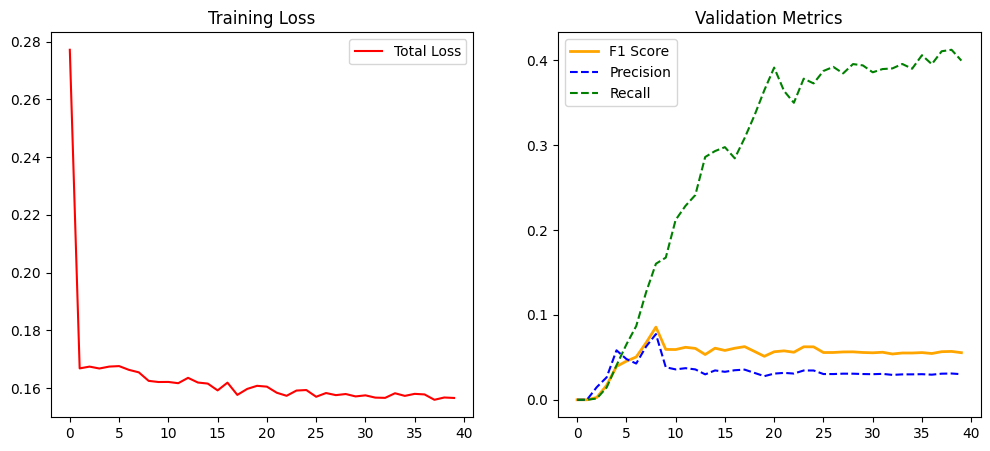

In [ ]:
import torch, torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

# --- 1. CONFIGURATION ---
CONF_THRESH = 0.05  # VERY low threshold to catch early learning
LR = 0.005          # Increased slightly for SGD

# --- 2. THE MODEL (MobileNetV3 Custom Backbone) ---
def build_custom_model(num_classes):
    # Load a lightweight backbone
    backbone_model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT).features
    backbone = backbone_model
    backbone.out_channels = 960 # Output channels for MobileNetV3 Large

    # Define anchors specifically for bone fractures (some small, some large)
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256, 512),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )

    # ROI Pooler
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )

    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )
    return model

# Initialize
model = build_custom_model(NUM_CLASSES).to(DEVICE)

# Optimizer: SGD usually works better for Faster R-CNN convergence than Adam
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LR, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# --- 3. TRAINING LOOP (With Detection Debugging) ---
history = {"loss": [], "precision": [], "recall": [], "f1": []}

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    num_batches = 0

    for images, targets in train_loader:
        valid_idx = [i for i, t in enumerate(targets) if t['boxes'].shape[0] > 0]
        if not valid_idx: continue

        images = [images[i].to(DEVICE) for i in valid_idx]
        targets = [{k: v.to(DEVICE) for k, v in targets[i].items()} for i in valid_idx]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        epoch_loss += losses.item()
        num_batches += 1

    # Validation
    model.eval()
    val_p, val_r, val_f = [], [], []
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(DEVICE) for img in images]
            preds = model(images)
            p, r, f = calculate_metrics(preds, targets, iou_thresh=0.5)
            val_p.append(p); val_r.append(r); val_f.append(f)

    # Store metrics
    avg_loss = epoch_loss / num_batches
    avg_f1 = np.mean(val_f)
    history["loss"].append(avg_loss)
    history["precision"].append(np.mean(val_p))
    history["recall"].append(np.mean(val_r))
    history["f1"].append(avg_f1)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | F1: {avg_f1:.4f}")
    scheduler.step()

# --- 4. VISUALIZATION ---
def plot_final_curves(hist):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(hist['loss'], label='Total Loss', color='red')
    plt.title('Training Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist['f1'], label='F1 Score', color='orange', linewidth=2)
    plt.plot(hist['precision'], label='Precision', color='blue', linestyle='--')
    plt.plot(hist['recall'], label='Recall', color='green', linestyle='--')
    plt.title('Validation Metrics')
    plt.legend()
    plt.show()

plot_final_curves(history)

i

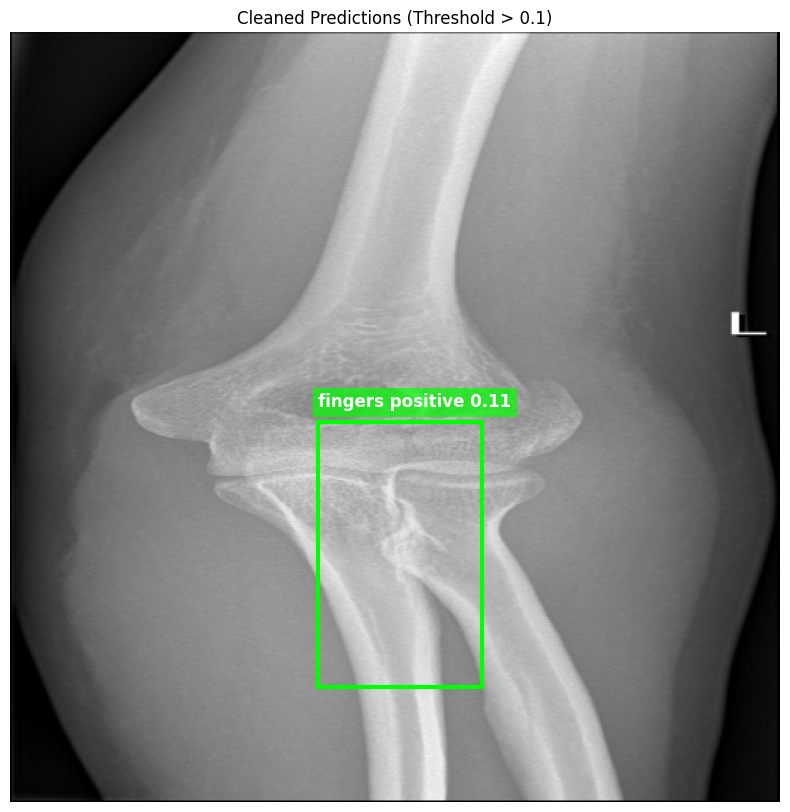

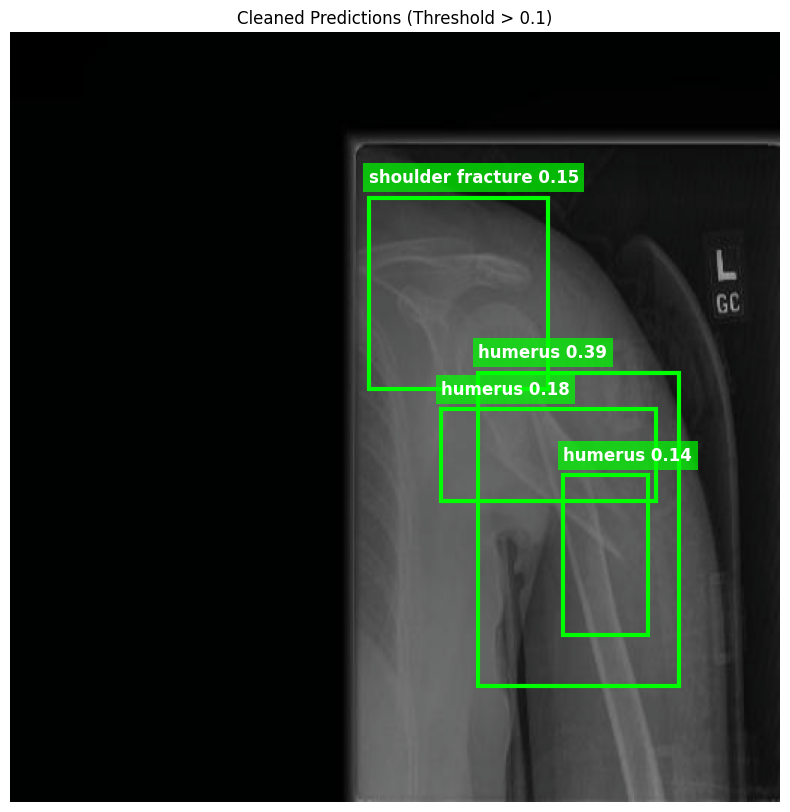

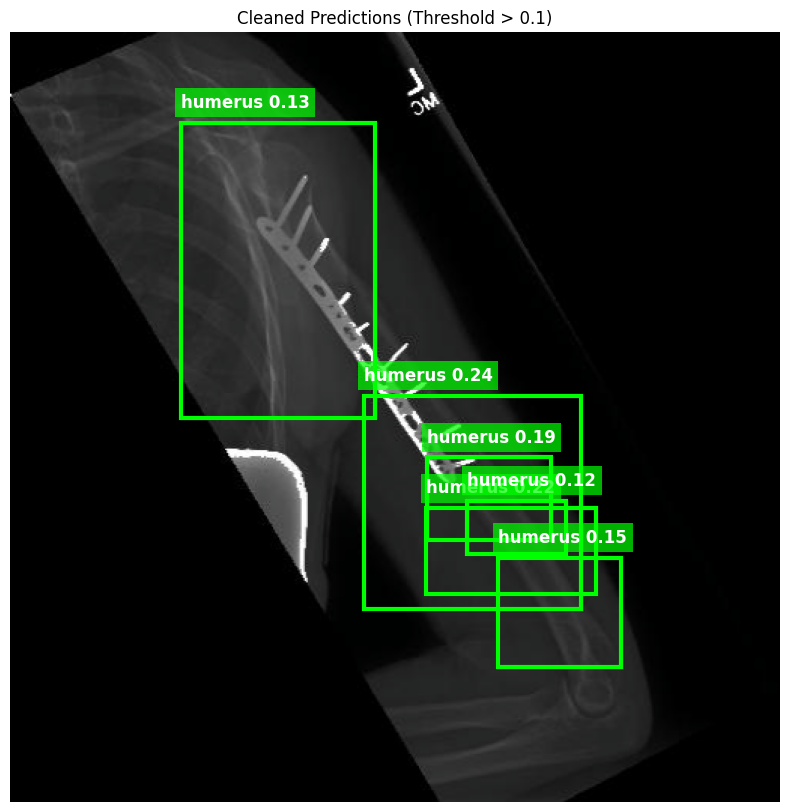

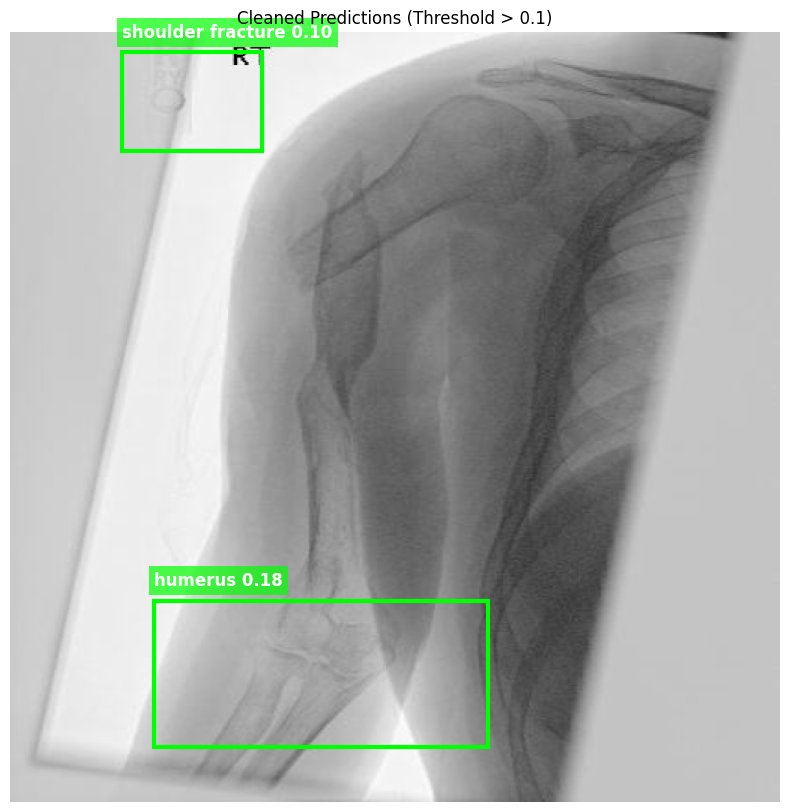

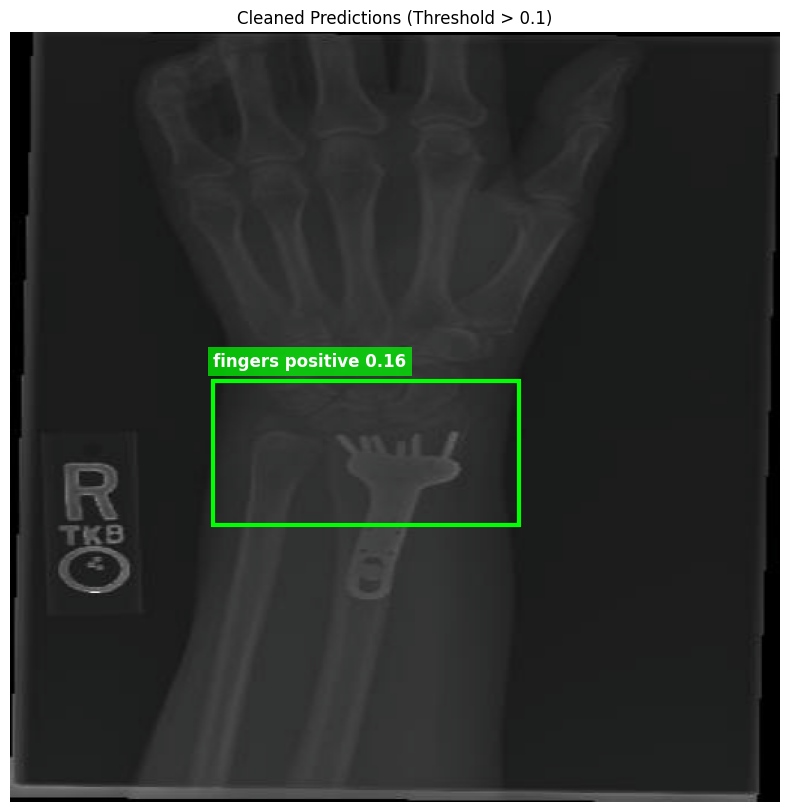

In [ ]:
import torchvision.ops as ops

def visualize_clean_predictions(model, loader, num_images=5, final_thresh=0.4):
    model.eval()
    images, _ = next(iter(loader))
    images_gpu = [img.to(DEVICE) for img in images]

    with torch.no_grad():
        predictions = model(images_gpu)

    for i in range(min(num_images, len(images))):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = (np.array([0.229, 0.224, 0.225]) * img + np.array([0.485, 0.456, 0.406]))
        img = np.clip(img, 0, 1)

        plt.figure(figsize=(10, 10))
        plt.imshow(img)
        ax = plt.gca()

        # 1. Get raw predictions
        boxes = predictions[i]['boxes']
        scores = predictions[i]['scores']
        labels = predictions[i]['labels']

        # 2. Apply NMS (Non-Maximum Suppression)
        # This removes overlapping boxes for the same object
        keep = ops.nms(boxes, scores, iou_threshold=0.3)

        boxes = boxes[keep].cpu().numpy()
        scores = scores[keep].cpu().numpy()
        labels = labels[keep].cpu().numpy()

        found = False
        for box, score, label in zip(boxes, scores, labels):
            # 3. Use a higher threshold for display (e.g., 0.4)
            if score > final_thresh:
                found = True
                x1, y1, x2, y2 = box
                rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                         fill=False, edgecolor='lime', linewidth=3)
                ax.add_patch(rect)

                class_name = CLASS_NAMES[label-1]
                ax.text(x1, y1-10, f"{class_name} {score:.2f}",
                        color='white', weight='bold', fontsize=12,
                        bbox=dict(facecolor='lime', alpha=0.7, edgecolor='none'))

        plt.axis('off')
        plt.title(f"Cleaned Predictions (Threshold > {final_thresh})")
        plt.show()

# Run the clean visualizer
visualize_clean_predictions(model, test_loader, final_thresh=0.1)

i
